# Package 3 – Upsell Classification: Analysis & Business Report

**Objective:** predict which customers are most likely to buy additional services (`upsell`, binary).

This notebook does **no additional model training**. It imports the already-fitted models, the prepared train/test split, and the cross-validation/holdout result tables directly from `upsell_classification.py` — importing it re-runs its cells once, which is how these become available here without retraining or recomputing anything. The one piece recreated directly in this notebook is the business-rule baseline, using thresholds computed from `X_train` only (not the whole dataset) so the rule is evaluated under the same train/test discipline as the models.

The goal is visual comparison and business interpretation, for both Data Science reviewers and Northbound Media's business stakeholders.

## 1. Setup & Data Leakage Prevention

Target: `upsell`. Leakage columns excluded before feature processing: `cumulative_profit` (only exists after the customer relationship has played out) and `referred` (typically only known after a customer has been active for a while) — both handled in `upsell_classification.py`'s `prepare_data()`. `referred` is also the only non-numeric column in the cleaned dataset, and since it's already excluded as leakage, no categorical encoding is required for the remaining features — all 16 are numeric. Train/test split: 80/20, stratified, `random_state=0`.

Shape: (3490, 19)
Number of features: 16
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'ltv_months', 'purchased']
Class balance (y):
upsell
0    0.579943
1    0.420057
Name: proportion, dtype: float64
X_train shape: (2792, 16)
X_test shape:  (698, 16)
y_train shape: (2792,)
y_test shape:  (698,)
Train class balance:
upsell
0    0.579871
1    0.420129
Name: proportion, dtype: float64


Trained XGBoost
Trained LightGBM
Trained CatBoost


Best model by 5-fold CV F1: CatBoost
True negatives:  287
False positives: 118  (predicted upsell, but customer did not buy)
False negatives: 37  (customer would upsell, but model missed them)
True positives:  256


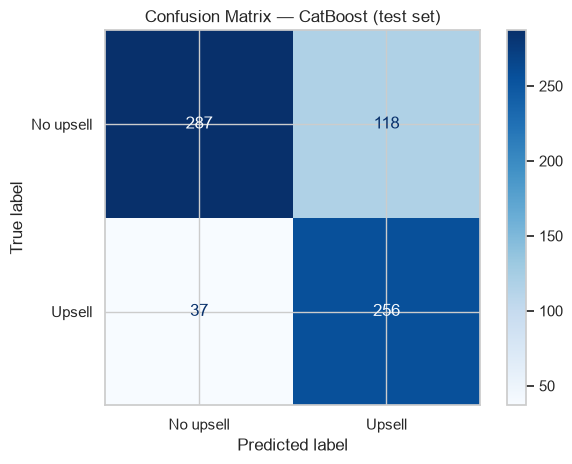

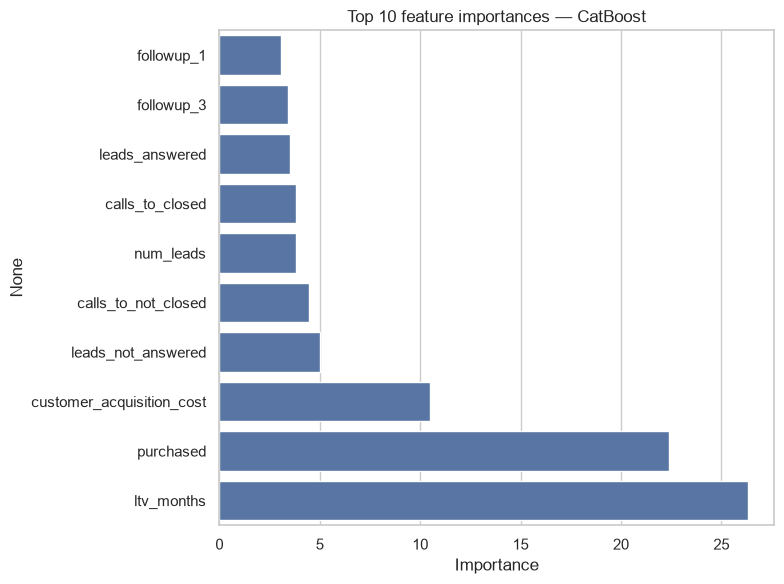

Top feature (ltv_months) share of total importance: 26.3%
Features: 16 | Train rows: 2792 | Test rows: 698


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from upsell_classification import (  # noqa: F401 (kept for reference/reproducibility)
    X_test,
    X_train,
    best_model,
    best_model_name,
    cm,
    cv_comparison,
    fn,
    fp,
    holdout_comparison,
    models,
    tn,
    top_10_features,
    top_share,
    tp,
    y_test,
    y_train,
)

sns.set_theme(style="whitegrid")
print(f"Features: {X_train.shape[1]} | Train rows: {len(X_train)} | Test rows: {len(X_test)}")

## 2. Model Training & 5-Fold Cross-Validation

Three classifiers, each with its own class-imbalance handling (the ~58/42 split makes raw accuracy an unreliable ranking signal on its own): `XGBClassifier(scale_pos_weight=...)`, `LGBMClassifier(class_weight="balanced")`, `CatBoostClassifier(auto_class_weights="Balanced")`. Evaluated with 5-fold **stratified** CV on `X_train`/`y_train` only — `X_test` stays untouched until final evaluation.

In [2]:
cv_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Greens"
).format(precision=3)

,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.797,0.711,0.872,0.783
1,LightGBM,0.781,0.695,0.853,0.766
2,XGBoost,0.761,0.686,0.796,0.737


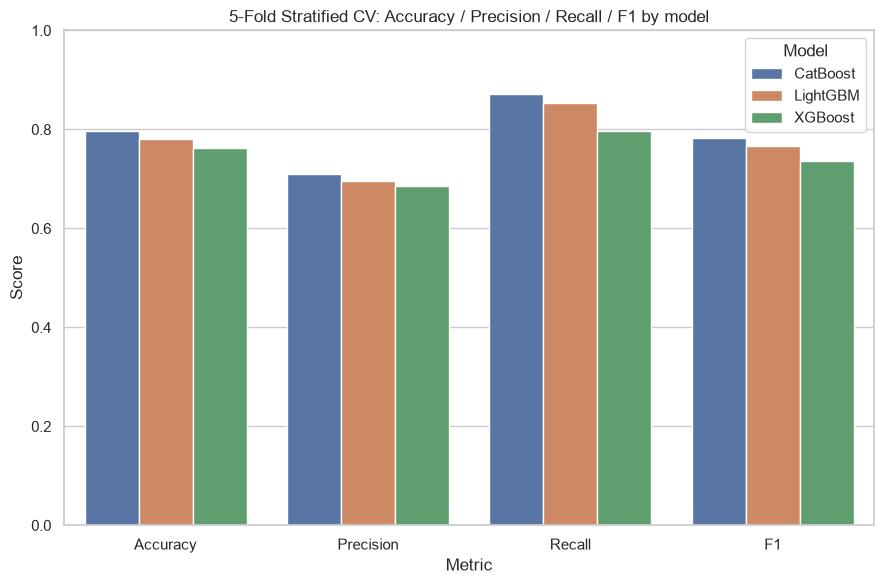

In [3]:
cv_long = cv_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 6))
sns.barplot(data=cv_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("5-Fold Stratified CV: Accuracy / Precision / Recall / F1 by model")
plt.tight_layout()
plt.show()

CatBoost leads on Recall and F1 rather than on the accuracy gap alone — the metric that matters most here, since a model that always predicted "no upsell" would already score ~58% accuracy without being useful. LightGBM tracks close behind; XGBoost trails both, most noticeably on Recall.

## 3. Final Evaluation & Business Rule Comparison

`best_model_name` was selected in `upsell_classification.py` by CV F1. Evaluated here on the held-out test set for the first time.

In [4]:
print(f"Selected model: {best_model_name}")
holdout_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Blues"
).format(precision=3)

Selected model: CatBoost


,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.778,0.684,0.874,0.768
1,LightGBM,0.766,0.672,0.867,0.757
2,XGBoost,0.748,0.669,0.792,0.725


CatBoost's holdout F1 (≈0.77) sits close to its CV F1 (≈0.78) — a small, expected gap in the direction cross-validation would predict, not a red flag — and it remains the best model on the untouched test set, not just in CV.

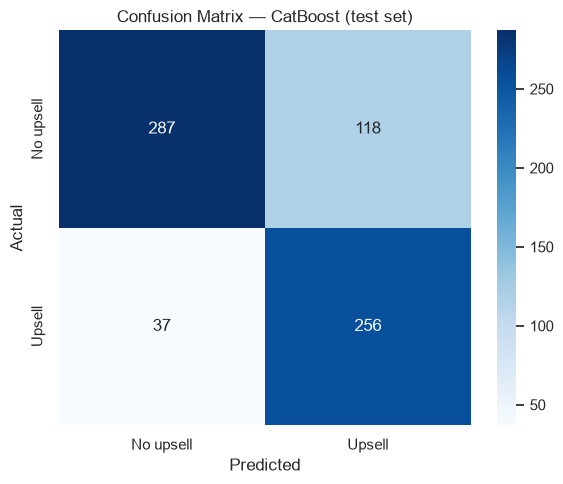

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No upsell", "Upsell"],
    yticklabels=["No upsell", "Upsell"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name} (test set)")
plt.tight_layout()
plt.show()

In [6]:
print(f"True negatives:  {tn}")
print(f"False positives: {fp}  (predicted upsell, customer did not buy — wasted outreach)")
print(f"False negatives: {fn}  (customer would upsell, model missed them — lost revenue)")
print(f"True positives:  {tp}")
print(f"False positive rate among predicted upsells: {fp / (fp + tp):.1%}")
print(f"False negative rate among actual upsells: {fn / (fn + tp):.1%}")

True negatives:  287
False positives: 118  (predicted upsell, customer did not buy — wasted outreach)
False negatives: 37  (customer would upsell, model missed them — lost revenue)
True positives:  256
False positive rate among predicted upsells: 31.6%
False negative rate among actual upsells: 12.6%


**Business trade-off of False Positives vs. False Negatives:** the model misses far fewer real upsell customers than it wrongly flags — only ~13% of actual upsell customers are missed (37 of 293), while ~32% of flagged customers turn out not to buy (118 of 374). In business terms, this model is tuned toward **not missing opportunity** at the cost of **some wasted outreach** — appropriate if an outreach touch is cheap relative to the value of a missed upsell, and worth revisiting if outreach capacity or cost per touch is the real constraint.

### Business Rule Baseline

Flag a customer for outreach if `ltv_months` is above the **train-set** median and `customer_acquisition_cost` is below the **train-set** median — no model required. Thresholds are computed from `X_train` (not the full dataset) so the rule is evaluated under the same train/test discipline as the models, and applied only to `X_test`.

In [7]:
ltv_threshold = X_train["ltv_months"].median()
cac_threshold = X_train["customer_acquisition_cost"].median()
print(f"Business rule thresholds (train-set medians): ltv_months > {ltv_threshold}, "
      f"customer_acquisition_cost < {cac_threshold}")

rule_pred_test = (
    (X_test["ltv_months"] > ltv_threshold)
    & (X_test["customer_acquisition_cost"] < cac_threshold)
).astype(int)

rule_row = pd.DataFrame(
    [
        {
            "Model": "Business rule",
            "Accuracy": accuracy_score(y_test, rule_pred_test),
            "Precision": precision_score(y_test, rule_pred_test),
            "Recall": recall_score(y_test, rule_pred_test),
            "F1": f1_score(y_test, rule_pred_test),
        }
    ]
)

rule_vs_model = pd.concat(
    [holdout_comparison[holdout_comparison["Model"] == best_model_name], rule_row],
    ignore_index=True,
)
rule_vs_model.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Oranges"
).format(precision=3)

Business rule thresholds (train-set medians): ltv_months > 21.0, customer_acquisition_cost < 1000.0


,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.778,0.684,0.874,0.768
1,Business rule,0.639,0.675,0.270,0.385


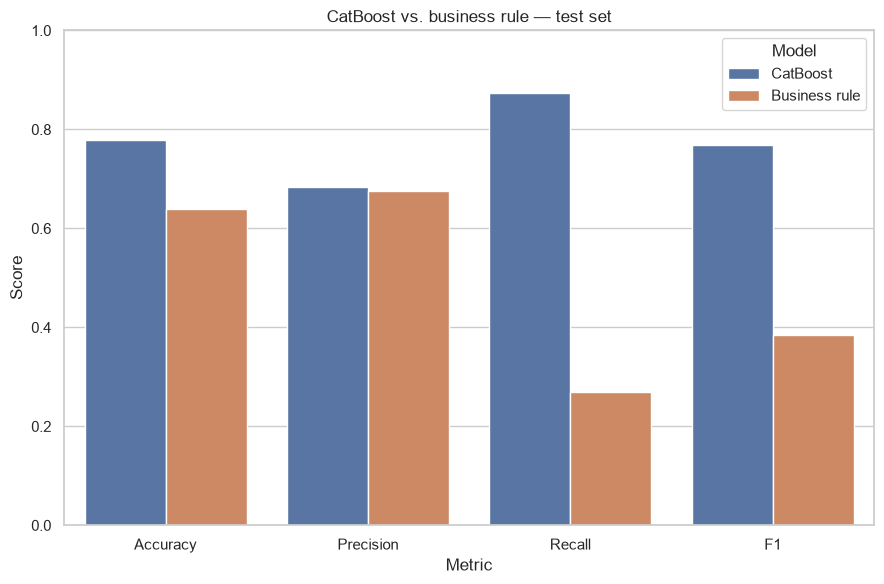

In [8]:
rule_long = rule_vs_model.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 6))
sns.barplot(data=rule_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title(f"{best_model_name} vs. business rule — test set")
plt.tight_layout()
plt.show()

**Where does the ML model outperform the rule?** Overwhelmingly on Recall — the two-threshold rule misses roughly three out of every four real upsell customers, while the model catches nearly nine out of ten. That drives most of the F1 gap.

**Where does the rule hold up?** Precision is close between the two — when the rule *does* flag someone, it's about as trustworthy as the model's flag. The rule's weakness isn't false alarms, it's that it's far too conservative and simply doesn't flag most of the customers who would actually upsell. For Northbound, that makes the two-threshold rule a reasonable quick filter for precision, but the ML model is substantially better for anyone trying to cover the full upsell opportunity rather than just the safest, most obvious cases.

## 4. Feature Importance & Executive Insights

In [9]:
top_10_features

ltv_months                   26.306789
purchased                    22.413961
customer_acquisition_cost    10.513148
leads_not_answered            5.007198
calls_to_not_closed           4.477520
num_leads                     3.817981
calls_to_closed               3.811879
leads_answered                3.526185
followup_3                    3.428764
followup_1                    3.043565
dtype: float64

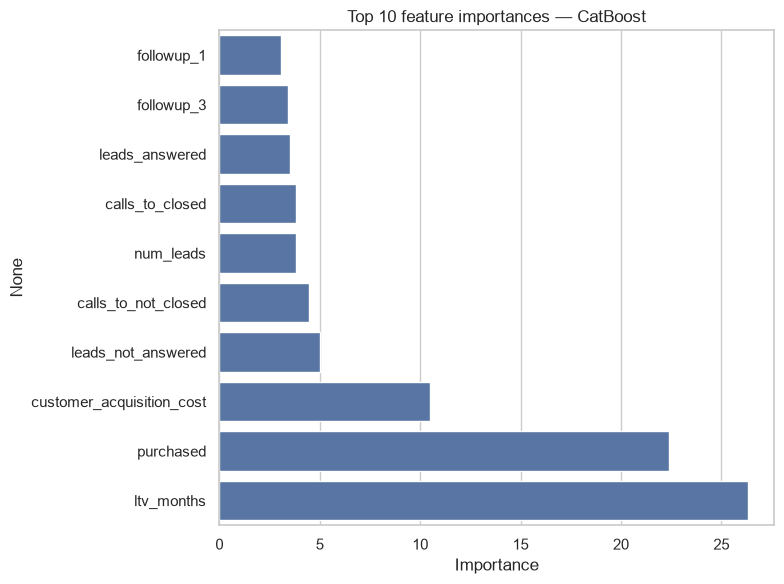

In [10]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title(f"Top 10 feature importances — {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Single dominant feature, or multi-factor drivers?** A combination, but a top-heavy one: `ltv_months` alone accounts for ~26% of total importance (`top_share` above), and together with `purchased` (~22%) the top two features carry roughly half of the model's decision-making. The remaining eight features in the top 10 each contribute a modest few percent (`customer_acquisition_cost`, funnel-volume columns, and follow-up counts), rounding out the picture rather than dominating it.

Two caveats worth flagging for a DS reviewer before this goes further: `purchased` is heavily imbalanced in the raw data (the large majority of rows already made an initial purchase), so its importance may partly reflect separating a small "never purchased" group rather than a nuanced upsell signal. `ltv_months` — kept as a feature per this package's brief — is the customer's full relationship length, which in practice may only be fully known well after the upsell decision point; treat its dominance as informative for understanding the data, but flag it before wiring this specific feature into a live prediction pipeline where lifetime isn't yet known.

### Strategic Recommendations

- **Prioritize outreach using the model, not the simple rule.** The business rule alone would leave roughly three-quarters of real upsell opportunity untouched; the model's much higher recall directly translates into more upsell revenue captured, at a similar precision to the rule.
- **Budget for the false-positive cost.** ~32% of customers the model flags won't convert — that's the expected cost of the recall-first tuning. If outreach is expensive (e.g. a dedicated account-manager call rather than an automated email), consider a lighter-touch first contact for flagged customers before committing higher-cost effort.
- **Watch lifetime and initial-purchase signals together, not lifetime alone.** Since `ltv_months` and `purchased` jointly carry about half the model's decision weight, customers who are already engaged for a while *and* have completed an initial purchase are the strongest upsell candidates — worth a standing segment in whatever CRM/outreach tooling Northbound uses next.
- **FunnelIQ integration:** the reusable functions in `upsell_classification.py` (`prepare_data`, `train_models`, `get_feature_importance`) are already structured to be imported by the FastAPI backend for a future `/predict/upsell` endpoint — no rewrite needed, just persisting the fitted model (see `models/`) and wiring a request schema.

These recommendations are tied directly to the CV/holdout metrics, the confusion matrix, the feature importances, and the rule-vs-model comparison above — not generic advice.

## Final Report Summary

*(Copy-ready for `README.md`.)*

```markdown
## Upsell Classification

### Objective

Predict which customers are most likely to buy additional services (`upsell`).

### Models

- XGBoost (`scale_pos_weight`)
- LightGBM (`class_weight="balanced"`)
- CatBoost (`auto_class_weights="Balanced"`)

### Evaluation

5-fold stratified cross-validation (on the training split only):

| Model    | Accuracy | Precision | Recall | F1    |
|----------|----------|-----------|--------|-------|
| CatBoost | 0.797    | 0.711     | 0.872  | 0.783 |
| LightGBM | 0.781    | 0.695     | 0.853  | 0.766 |
| XGBoost  | 0.761    | 0.686     | 0.796  | 0.737 |

Final held-out test performance (CatBoost, selected model):

| Model    | Accuracy | Precision | Recall | F1    |
|----------|----------|-----------|--------|-------|
| CatBoost | 0.778    | 0.684     | 0.874  | 0.768 |

Confusion matrix (test set, CatBoost): 287 true negatives, 118 false positives,
37 false negatives, 256 true positives.

### Key Findings

- **Model selected by F1, not accuracy** — the ~58/42 class imbalance makes raw
  accuracy misleading; F1 balances catching real upsells against wasted outreach.
- **Feature importance is top-heavy but not single-feature:** `ltv_months`
  (~26%) and `purchased` (~22%) together carry about half the model's decisions,
  with eight more features contributing smaller shares.
- **The ML model substantially beats a simple business rule** (`ltv_months` and
  `customer_acquisition_cost` thresholds, computed from the train set): F1 0.77
  vs. 0.39, driven almost entirely by much higher recall (0.87 vs. 0.27) at
  similar precision.

### Data Leakage Decision

`cumulative_profit` and `referred` were excluded from the feature set, for the
same reason as the LTV regression task: both are outcomes that only exist after
the customer relationship has played out, so they wouldn't be available at the
moment an upsell prediction is actually needed.
```